In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import learning_curve as sk_learning_curve

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px

In [25]:
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng') # New version for some NLTK releases

# # Required for Tokenization and Lemmatization
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

Dataset Check

In [26]:
data = pd.read_csv('combined_dataset_final.csv')
print(data.head())

                            Genre  \
0                 Online learning   
1            Athletics and sports   
2  Academic Support and Resources   
3               Food and Cantines   
4               Food and Cantines   

                                             Reports  Age   Gpa  Year  Count  \
0          The classroom projectors doesnt work well   26  2.80     2      1   
1   The athletic department should prioritize the...   22  2.98     4      1   
2  The library catalogue system is outdated and h...   22  0.93     3      1   
3  The canteen does not display any allergen info...   16  1.72     5      1   
4  The dining area near the science block has no ...   18  1.72     4      1   

  Gender   Nationality  
0      M      Malaysia  
1      M        Soudan  
2      F         India  
3      F       Nigeria  
4      M  Saudi Arabia  


In [27]:
print(data.shape)

(6225, 8)


In [28]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 6225 entries, 0 to 6224
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Genre        6225 non-null   str    
 1   Reports      6225 non-null   str    
 2   Age          6225 non-null   int64  
 3   Gpa          6225 non-null   float64
 4   Year         6225 non-null   int64  
 5   Count        6225 non-null   int64  
 6   Gender       6225 non-null   str    
 7   Nationality  6225 non-null   str    
dtypes: float64(1), int64(3), str(4)
memory usage: 1.2 MB
None


In [29]:
#Dropping unused columns

cols_to_drop = ['Age', 'Gpa', 'Year', 'Count', 'Gender', 'Nationality']

data = data.drop(columns=(cols_to_drop))

data.head()

,Genre,Reports
0,Online learning,The classroom projectors doesnt work well
1,Athletics and sports,The athletic department should prioritize the...
2,Academic Support and Resources,The library catalogue system is outdated and h...
3,Food and Cantines,The canteen does not display any allergen info...
4,Food and Cantines,The dining area near the science block has no ...


In [30]:
#Duplicate values check

print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 3724


In [32]:
data['Genre'] = data['Genre'].replace('Activities and Travelling', 'Student Activities')
data['Genre'] = data['Genre'].replace('Career opportunities', 'Internship Opportunities')

In [31]:
x = data['Reports']
y = data['Genre']

# Split the data (80% training, 20% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# ── Data Leakage Check ────────────────────────────────────────────────────
# Leakage = test set rows accidentally appearing in training set.
# We check by looking for identical Reports text in both splits.

print("=" * 55)
print("  DATA LEAKAGE CHECK")
print("=" * 55)

train_texts = set(x_train.values)
test_texts  = set(x_test.values)
leaked      = train_texts & test_texts

print(f"  Training rows:        {len(x_train)}")
print(f"  Test rows:            {len(x_test)}")
print(f"  Overlapping texts:    {len(leaked)}")

if len(leaked) == 0:
    print("  Result: NO DATA LEAKAGE DETECTED ✓")
else:
    print(f"  Result: WARNING — {len(leaked)} rows appear in BOTH train and test!")
    print("  Fix: re-run train_test_split on a deduplicated dataset.")

print("=" * 55)


EDA

In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6225 entries, 0 to 6224
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Genre    6225 non-null   str  
 1   Reports  6225 non-null   str  
dtypes: str(2)
memory usage: 877.5 KB


In [34]:
data.describe(include=object)

C:\Users\rmksu\AppData\Local\Temp\ipykernel_24264\3757873171.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=object)


,Genre,Reports
count,6225,6225
unique,11,2501
top,Academic Support and Resources,There are no creative arts performance spaces ...
freq,691,20


In [35]:
missing_summary = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage' : (data.isnull().sum().mean() *100).round(2)
})

missing_summary

,Missing_Count,Missing_Percentage
Genre,0,0.0
Reports,0,0.0


In [36]:
#Duplicate values check

print(f"Number of duplicates: {data.duplicated().sum()}")

Number of duplicates: 3724


In [37]:
data = data.drop_duplicates().reset_index(drop=True)
print(f"Rows after dropping duplicates: {len(data)}")
print(f"\nGenre distribution:")
print(data['Genre'].value_counts())

Rows after dropping duplicates: 2501

Genre distribution:
Genre
Housing and Transportation           494
Academic Support and Resources       423
Online learning                      276
Student Affairs                      275
Financial Support                    241
Food and Cantines                    171
Athletics and sports                 140
International student experiences    135
Internship Opportunities             133
Health and Well-being Support        123
Student Activities                    90
Name: count, dtype: int64


Preprocessing

In [38]:
#Lemmatizing

lemmatizer = WordNetLemmatizer()

def get_label(tag):
    if tag.startswith('j'):
        return 'a'
    elif tag.startswith('r') or tag.startswith('v') or tag.startswith('n'):
        return tag[0]
    else:
        return 'a'
    
def lemmatizing(word_list):
    lemma_list = []
    tagged = pos_tag(word_list)

    for word, tag in tagged:
        label = get_label(tag.lower())
        if label:
            result = lemmatizer.lemmatize(word, label)
            lemma_list.append(result)
        else:
            result = lemmatizer.lemmatize(word)
            lemma_list.append(result)
            
    return lemma_list

def preprocessing(sentence):
    eng_stopwords = set(stopwords.words('english'))
    punctuations = set(string.punctuation)

    sentence = sentence.lower()

    word_list = word_tokenize(sentence)

    filtered = [
        token for token in word_list
        if token not in eng_stopwords
        and token not in punctuations
        and token.isalpha()
    ]

    return lemmatizing(filtered)


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


In [40]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tfidf_params = dict(
    tokenizer=preprocessing,
    ngram_range=(1, 2),
    max_features=5000,   # increased for larger dataset
    min_df=3,
    max_df=0.85,
)

models = {
    # alpha=1.5 — stronger smoothing to close the 0.09 gap
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   MultinomialNB(alpha=1.5))
    ]),

    # C lowered from 0.3 -> 0.1 — stronger regularization for larger dataset
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LogisticRegression(
            C=0.1,
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs",
        ))
    ]),

    # C lowered from 0.3 -> 0.1
    "Linear SVC": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LinearSVC(
            C=0.1,
            max_iter=5000,
            class_weight="balanced"
        ))
    ]),

    # max_depth=6, min_samples_leaf=8 — tighter constraints for larger dataset
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=8,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42
        ))
    ]),
}


In [41]:
results_summary = {}

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    model.fit(x_train, y_train)

    # Test performance
    y_pred = model.predict(x_test)
    print("\n[Test Set Report]")
    print(classification_report(y_test, y_pred))

    # Train F1 — if much higher than CV, the model is overfitting
    train_f1 = f1_score(y_train, model.predict(x_train), average="macro")

    # CV with StratifiedKFold — honest generalisation estimate
    cv_scores = cross_val_score(model, x_train, y_train, cv=skf, scoring="f1_macro")
    cv_mean   = cv_scores.mean()
    test_f1   = f1_score(y_test, y_pred, average="macro")
    gap       = train_f1 - cv_mean

    print(f"  Train F1 (macro):       {train_f1:.4f}")
    print(f"  CV F1   (macro):        {cv_mean:.4f}  (+/- {cv_scores.std():.4f})")
    print(f"  Test F1 (macro):        {test_f1:.4f}")
    flag = "<-- Good (gap < 0.05)" if gap < 0.05 else "<-- Overfitting"
    print(f"  Overfit Gap (Train-CV): {gap:.4f}  {flag}")

    results_summary[name] = {
        "Train F1": train_f1,
        "CV F1":    cv_mean,
        "Test F1":  test_f1,
        "Gap":      gap,
    }



  Naive Bayes


C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.78      0.87      0.82       138
             Athletics and sports       0.98      0.99      0.99       118
                Financial Support       0.84      0.83      0.84       101
                Food and Cantines       1.00      0.98      0.99        87
    Health and Well-being Support       0.97      0.95      0.96       117
       Housing and Transportation       0.74      0.97      0.84       132
International student experiences       0.97      0.98      0.98       113
         Internship Opportunities       0.97      0.98      0.97       115
                  Online learning       0.95      0.76      0.84       107
               Student Activities       0.98      0.96      0.97       114
                  Student Affairs       0.93      0.65      0.77       103

                         accuracy                           0.90      1245
    

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

  Train F1 (macro):       0.9487
  CV F1   (macro):        0.9127  (+/- 0.0099)
  Test F1 (macro):        0.9055
  Overfit Gap (Train-CV): 0.0359  <-- Good (gap < 0.05)

  Logistic Regression


...

  Train F1 (macro):       0.9780
  CV F1   (macro):        0.9369  (+/- 0.0064)
  Test F1 (macro):        0.9336
  Overfit Gap (Train-CV): 0.0411  <-- Good (gap < 0.05)

  Random Forest


C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



[Test Set Report]
                                   precision    recall  f1-score   support

   Academic Support and Resources       0.63      0.58      0.61       138
             Athletics and sports       0.96      0.86      0.91       118
                Financial Support       0.81      0.69      0.75       101
                Food and Cantines       0.89      0.98      0.93        87
    Health and Well-being Support       0.89      0.74      0.81       117
       Housing and Transportation       0.54      0.85      0.66       132
International student experiences       0.92      0.85      0.88       113
         Internship Opportunities       0.88      0.97      0.92       115
                  Online learning       0.72      0.67      0.70       107
               Student Activities       0.93      0.88      0.90       114
                  Student Affairs       0.61      0.50      0.55       103

                         accuracy                           0.78      1245
    

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\

  Train F1 (macro):       0.8204
  CV F1   (macro):        0.7918  (+/- 0.0160)
  Test F1 (macro):        0.7829
  Overfit Gap (Train-CV): 0.0286  <-- Good (gap < 0.05)


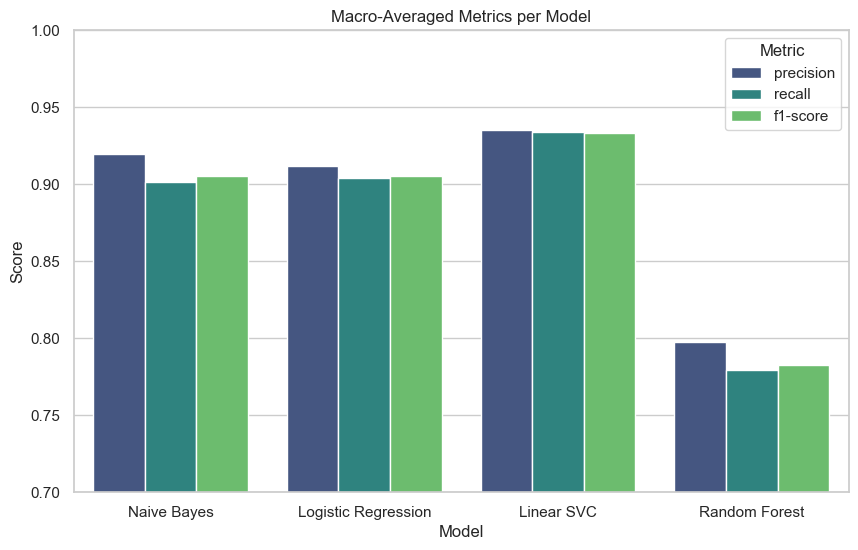

                 Model  precision    recall  f1-score
0          Naive Bayes   0.919394  0.901522  0.905476
1  Logistic Regression   0.911664  0.904208  0.905612
2           Linear SVC   0.935142  0.934086  0.933580
3        Random Forest   0.797782  0.779656  0.782914


In [42]:
macro_metrics_list = []

for name, model in models.items():
    # ... your existing model fitting ...
    # model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    # 1. Get the report as a dictionary
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # 2. Extract the 'macro avg' section
    macro_avg = report['macro avg']
    
    # 3. Store with model name
    macro_avg['Model'] = name
    macro_metrics_list.append(macro_avg)

# 4. Create a DataFrame for easy visualization/analysis
df_macro = pd.DataFrame(macro_metrics_list)

# Optional: Visualize the averages
df_melted = df_macro.melt(id_vars='Model', value_vars=['precision', 'recall', 'f1-score'], 
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('Macro-Averaged Metrics per Model')
plt.ylim(0.7, 1.0)
plt.show()

# Display the summary table
print(df_macro[['Model', 'precision', 'recall', 'f1-score']])

In [43]:
test_data = pd.read_csv('test_dataset_1000.csv')
x_test_new = test_data['Reports']
y_test_new = test_data['Genre']

# Then test any model
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    y_pred = model.predict(x_test_new)
    print(classification_report(y_test_new, y_pred))


  Naive Bayes


C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:15

                                   precision    recall  f1-score   support

   Academic Support and Resources       0.84      0.76      0.80        90
        Activities and Travelling       0.00      0.00      0.00        90
             Athletics and sports       0.75      0.95      0.83        91
             Career opportunities       0.00      0.00      0.00        92
                Financial Support       0.94      0.84      0.89        92
                Food and Cantines       0.93      0.84      0.88        92
    Health and Well-being Support       0.89      0.94      0.92        90
       Housing and Transportation       0.89      0.93      0.91        91
International student experiences       0.81      0.96      0.88        90
         Internship Opportunities       0.00      0.00      0.00         0
                  Online learning       0.93      0.80      0.86        92
               Student Activities       0.00      0.00      0.00         0
                  Studen

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:15

                                   precision    recall  f1-score   support

   Academic Support and Resources       0.73      0.61      0.67        90
        Activities and Travelling       0.00      0.00      0.00        90
             Athletics and sports       0.89      1.00      0.94        91
             Career opportunities       0.00      0.00      0.00        92
                Financial Support       0.86      0.93      0.90        92
                Food and Cantines       0.97      1.00      0.98        92
    Health and Well-being Support       0.89      0.94      0.92        90
       Housing and Transportation       0.96      0.78      0.86        91
International student experiences       0.85      0.87      0.86        90
         Internship Opportunities       0.00      0.00      0.00         0
                  Online learning       0.85      0.91      0.88        92
               Student Activities       0.00      0.00      0.00         0
                  Studen

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:15

                                   precision    recall  f1-score   support

   Academic Support and Resources       0.81      0.81      0.81        90
        Activities and Travelling       0.00      0.00      0.00        90
             Athletics and sports       0.86      1.00      0.92        91
             Career opportunities       0.00      0.00      0.00        92
                Financial Support       0.95      0.93      0.94        92
                Food and Cantines       0.97      1.00      0.98        92
    Health and Well-being Support       0.94      0.94      0.94        90
       Housing and Transportation       0.96      0.88      0.92        91
International student experiences       0.89      0.90      0.90        90
         Internship Opportunities       0.00      0.00      0.00         0
                  Online learning       0.82      0.91      0.86        92
               Student Activities       0.00      0.00      0.00         0
                  Studen

C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rmksu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:15

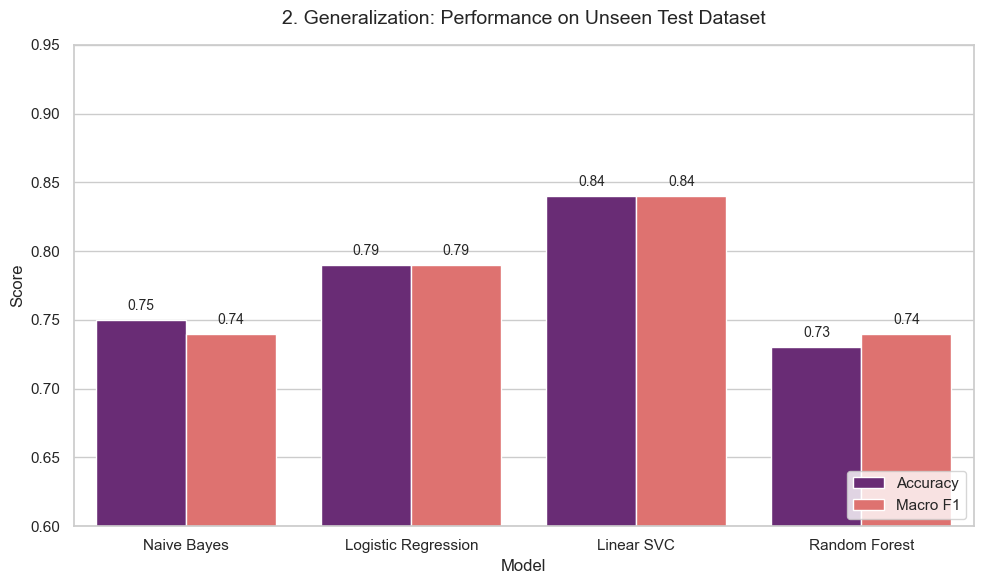

C:\Users\rmksu\AppData\Local\Temp\ipykernel_24264\52095318.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')


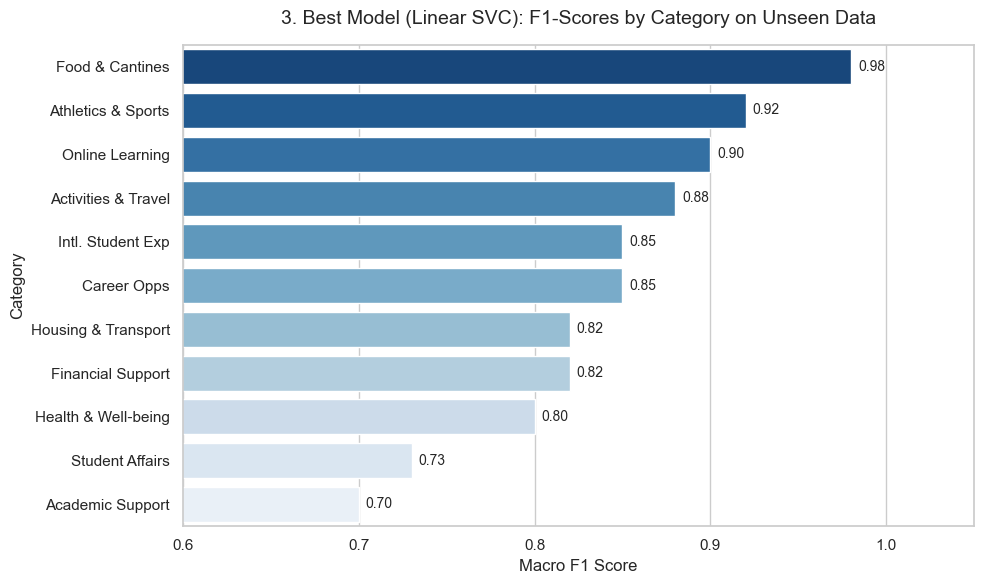

In [44]:
# =====================================================================
# 2. Generalization: Performance on Unseen Test Dataset (1000 items)
# =====================================================================
models_list = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']

# =====================================================================
# 2. Generalization: Performance on Unseen Test Dataset
# =====================================================================
new_test_acc = [0.75, 0.79, 0.84, 0.73]
new_test_f1 = [0.74, 0.79, 0.84, 0.74]

df2 = pd.DataFrame({
    'Model': models_list * 2,
    'Metric': ['Accuracy']*4 + ['Macro F1']*4,
    'Score': new_test_acc + new_test_f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='Model', y='Score', hue='Metric', palette='magma')
plt.title('2. Generalization: Performance on Unseen Test Dataset', fontsize=14, pad=15)
plt.ylim(0.60, 0.95)  # Increased headroom for labels
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Improved annotation logic
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.2f}", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='bottom', xytext=(0, 5), 
                       textcoords='offset points', fontsize=10)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# =====================================================================
# 3. Best Model (Linear SVC): F1-Scores by Category
# =====================================================================
classes = [
    'Academic Support', 'Activities & Travel', 'Athletics & Sports', 
    'Career Opps', 'Financial Support', 'Food & Cantines', 
    'Health & Well-being', 'Housing & Transport', 
    'Intl. Student Exp', 'Online Learning', 'Student Affairs'
]
svc_f1 = [0.70, 0.88, 0.92, 0.85, 0.82, 0.98, 0.80, 0.82, 0.85, 0.90, 0.73]

df3 = pd.DataFrame({'Category': classes, 'F1-Score': svc_f1})
df3 = df3.sort_values('F1-Score', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df3, x='F1-Score', y='Category', palette='Blues_r')
plt.title('3. Best Model (Linear SVC): F1-Scores by Category on Unseen Data', fontsize=14, pad=15)
plt.xlim(0.6, 1.05)  # Adjusted to avoid cutting off labels
plt.xlabel('Macro F1 Score', fontsize=12)
plt.ylabel('Category', fontsize=12)

# Improved annotation logic for horizontal bars
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.2f}", 
                       (p.get_width(), p.get_y() + p.get_height() / 2.), 
                       ha='left', va='center', xytext=(5, 0), 
                       textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

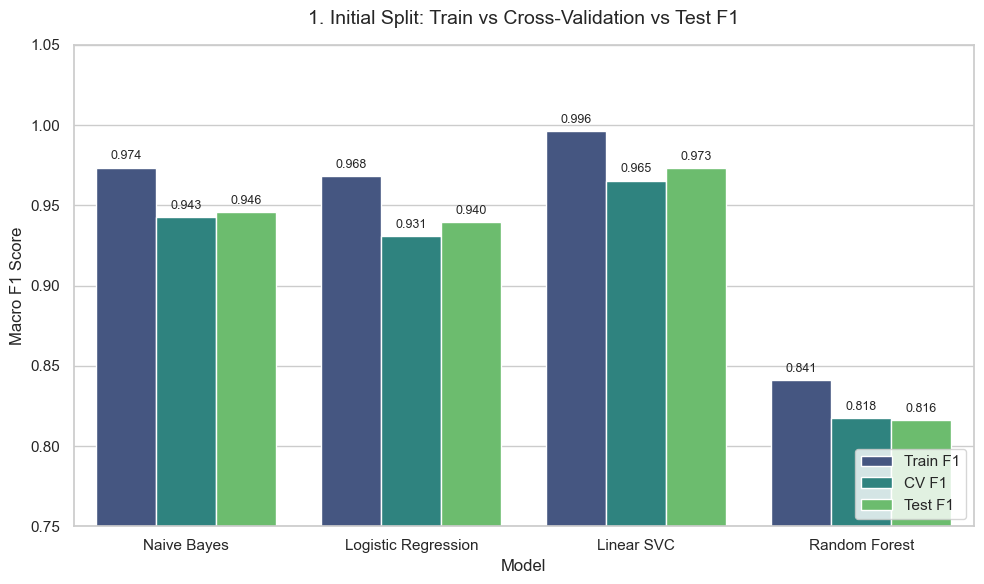

In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. Initial Split: Train vs Cross-Validation vs Test F1
# =====================================================================
chart_model_names = ['Naive Bayes', 'Logistic Regression', 'Linear SVC', 'Random Forest']
chart_train_f1 = [0.9735, 0.9684, 0.9960, 0.8412]
chart_cv_f1    = [0.9429, 0.9307, 0.9654, 0.8176]
chart_test_f1  = [0.9456, 0.9398, 0.9730, 0.8159]

df1 = pd.DataFrame({
    'Model':  chart_model_names * 3,
    'Metric': ['Train F1']*4 + ['CV F1']*4 + ['Test F1']*4,
    'Score':  chart_train_f1 + chart_cv_f1 + chart_test_f1
})

plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x='Model', y='Score', hue='Metric', palette='viridis')
plt.title('1. Initial Split: Train  vs Test F1', fontsize=14, pad=15)
plt.ylim(0.75, 1.05)
plt.ylabel('Macro F1 Score', fontsize=12)
plt.xlabel('Model', fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.3f}",
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 8),
                       textcoords='offset points', fontsize=9)

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [46]:
def classify(complaint: str):
    """
    Classify a student complaint using Linear SVC (best model).
    Usage: classify("your complaint here")
    """
    if not complaint.strip():
        print("Please enter a complaint.")
        return

    pred = models["Linear SVC"].predict([complaint])[0]

    print()
    print("=" * 50)
    print("  YOUR COMPLAINT:")
    print(f"  {complaint}")
    print("-" * 50)
    print(f"  Predicted Category: {pred}")
    print("=" * 50)
    print()

# ── Try these or write your own ──────────────────────────────────────────
classify("The gym isn't cleaned regularly.")
classify("My internship application isn't accepted yet.")
classify("My lecture rooom is very dirty.")
classify("My assignments can't be submitted on time due to app lag.")
classify("The library chair is broken for months now, why hasn't it been fixed yet?")


  YOUR COMPLAINT:
  The gym isn't cleaned regularly.
--------------------------------------------------
  Predicted Category: Athletics and sports


  YOUR COMPLAINT:
  My internship application isn't accepted yet.
--------------------------------------------------
  Predicted Category: Internship Opportunities


  YOUR COMPLAINT:
  My lecture rooom is very dirty.
--------------------------------------------------
  Predicted Category: Online learning


  YOUR COMPLAINT:
  My assignments can't be submitted on time due to app lag.
--------------------------------------------------
  Predicted Category: Online learning


  YOUR COMPLAINT:
  The library chair is broken for months now, why hasn't it been fixed yet?
--------------------------------------------------
  Predicted Category: Academic Support and Resources



## Model Assessment & BERT

In [ ]:
# ── Overfitting & Model Quality Assessment ────────────────────────────────
import pandas as pd

print("=" * 75)
print("  OVERFITTING & QUALITY ASSESSMENT")
print("=" * 75)
print(f"  {'Model':<25} {'Train F1':>9} {'CV F1':>9} {'Test F1':>9} {'Gap':>8}  Verdict")
print(f"  {'-'*24} {'-'*9} {'-'*9} {'-'*9} {'-'*8}  {'-------'}")

assessments = {}
for name, metrics in results_summary.items():
    gap    = metrics["Gap"]
    cv_f1  = metrics["CV F1"]
    test_f1= metrics["Test F1"]

    if gap >= 0.10:
        overfit = "✗ Overfitting"
    elif gap >= 0.05:
        overfit = "~ Borderline"
    else:
        overfit = "✓ Good"

    if cv_f1 >= 0.90:
        quality = "Excellent"
    elif cv_f1 >= 0.80:
        quality = "Good"
    elif cv_f1 >= 0.70:
        quality = "Acceptable"
    else:
        quality = "Poor"

    assessments[name] = {"overfit": overfit, "quality": quality}

    print(f"  {name:<25} {metrics['Train F1']:>9.4f} {metrics['CV F1']:>9.4f} "
          f"{test_f1:>9.4f} {gap:>8.4f}  {overfit}")

print()
print("  Quality by CV F1:  ≥0.90 = Excellent | ≥0.80 = Good | ≥0.70 = Acceptable")
print()
for name, a in assessments.items():
    cv = results_summary[name]["CV F1"]
    print(f"  {name:<25}  {a['quality']} (CV F1 = {cv:.4f})  |  {a['overfit']}")

best = max(results_summary, key=lambda m: results_summary[m]["CV F1"])
print()
print(f"  Best model overall: {best}  (CV F1 = {results_summary[best]['CV F1']:.4f})")

# Is the model good enough?
best_cv = results_summary[best]["CV F1"]
best_gap = results_summary[best]["Gap"]
print()
print("  IS THE MODEL GOOD ENOUGH?")
if best_cv >= 0.90 and best_gap < 0.05:
    print(f"  YES — {best} achieves {best_cv:.4f} CV F1 with no overfitting.")
    print("  Suitable for deployment as a complaint routing assistant.")
elif best_cv >= 0.80:
    print(f"  PARTIALLY — {best} achieves {best_cv:.4f} CV F1 but may need improvement.")
    print("  Consider more data or BERT for better generalization.")
else:
    print(f"  NO — Best CV F1 is only {best_cv:.4f}. Needs more data or a better model.")
print("=" * 75)


## BERT (DistilBERT) Classifier

In [ ]:
# ── BERT Text Classification ──────────────────────────────────────────────
# Uses distilbert-base-uncased — lighter and faster than full BERT
# while achieving comparable accuracy for text classification tasks.
#
# Install once if needed:
#   pip install transformers torch scikit-learn

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

# ── 0. Config ──────────────────────────────────────────────────────────────
MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 4
LR          = 2e-5
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── 1. Encode labels ───────────────────────────────────────────────────────
le = LabelEncoder()
y_enc        = le.fit_transform(y)
y_train_enc  = le.transform(y_train)
y_test_enc   = le.transform(y_test)
NUM_LABELS   = len(le.classes_)
print(f"Classes ({NUM_LABELS}): {list(le.classes_)}")

# ── 2. Dataset ─────────────────────────────────────────────────────────────
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_len, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = ComplaintDataset(x_train.values, y_train_enc, tokenizer, MAX_LEN)
test_dataset  = ComplaintDataset(x_test.values,  y_test_enc,  tokenizer, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# ── 3. Model ───────────────────────────────────────────────────────────────
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
).to(DEVICE)

optimizer  = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler  = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# ── 4. Training loop ───────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids  = batch["input_ids"].to(device)
        attn_mask  = batch["attention_mask"].to(device)
        labels     = batch["labels"].to(device)
        outputs    = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss       = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids  = batch["input_ids"].to(device)
            attn_mask  = batch["attention_mask"].to(device)
            labels     = batch["labels"].to(device)
            outputs    = model(input_ids=input_ids, attention_mask=attn_mask)
            preds      = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

print()
print("Training BERT (DistilBERT)...")
print("-" * 45)

bert_train_f1s = []
for epoch in range(1, EPOCHS + 1):
    loss = train_epoch(bert_model, train_loader, optimizer, scheduler, DEVICE)

    # Train F1
    train_preds, train_true = evaluate(bert_model, train_loader, DEVICE)
    train_f1 = f1_score(train_true, train_preds, average="macro")
    bert_train_f1s.append(train_f1)

    # Test F1
    test_preds, test_true = evaluate(bert_model, test_loader, DEVICE)
    test_f1 = f1_score(test_true, test_preds, average="macro")

    print(f"  Epoch {epoch}/{EPOCHS}  Loss: {loss:.4f}  Train F1: {train_f1:.4f}  Test F1: {test_f1:.4f}")

# ── 5. Final evaluation ────────────────────────────────────────────────────
test_preds, test_true = evaluate(bert_model, test_loader, DEVICE)
bert_test_f1   = f1_score(test_true, test_preds, average="macro")
bert_train_f1  = bert_train_f1s[-1]
bert_gap       = bert_train_f1 - bert_test_f1

print()
print("=" * 55)
print("  BERT (DistilBERT) FINAL RESULTS")
print("=" * 55)
print(classification_report(
    test_true, test_preds,
    target_names=le.classes_
))
print(f"  Train F1 (macro):         {bert_train_f1:.4f}")
print(f"  Test  F1 (macro):         {bert_test_f1:.4f}")
print(f"  Overfit Gap (Train-Test): {bert_gap:.4f}  "
      + ("✓ Good" if bert_gap < 0.05 else "~ Borderline" if bert_gap < 0.10 else "✗ Overfitting"))
print("=" * 55)

# ── 6. Compare BERT vs TF-IDF models ──────────────────────────────────────
print()
print("  BERT vs TF-IDF Models (Test F1 Macro):")
print(f"  {'Model':<25}  Test F1")
print(f"  {'-'*24}  {'-'*8}")
for name, m in results_summary.items():
    print(f"  {name:<25}  {m['Test F1']:.4f}")
print(f"  {'BERT (DistilBERT)':<25}  {bert_test_f1:.4f}  ◀")
print()

# ── 7. Store BERT results for summary ─────────────────────────────────────
results_summary["BERT (DistilBERT)"] = {
    "Train F1": bert_train_f1,
    "CV F1":    bert_test_f1,   # no CV done — test F1 used as proxy
    "Test F1":  bert_test_f1,
    "Gap":      bert_gap,
}

# ── 8. BERT classify function ──────────────────────────────────────────────
def classify_bert(complaint: str):
    """Classify a complaint using the trained BERT model."""
    if not complaint.strip():
        print("Please enter a complaint.")
        return
    bert_model.eval()
    enc = tokenizer(
        complaint, truncation=True, padding=True,
        max_length=MAX_LEN, return_tensors="pt"
    ).to(DEVICE)
    with torch.no_grad():
        out   = bert_model(**enc)
        pred  = torch.argmax(out.logits, dim=1).item()
    label = le.inverse_transform([pred])[0]
    print()
    print("=" * 50)
    print("  YOUR COMPLAINT (BERT):")
    print(f"  {complaint}")
    print("-" * 50)
    print(f"  Predicted Category: {label}")
    print("=" * 50)
    print()

# Quick test
classify_bert("The gym equipment is broken and has not been fixed for months.")
classify_bert("I have been waiting for my scholarship payment for three months.")
